# L1 vs L2

Сравниваем две редукции дельты активаций side by side для классификатора и детектора:

- `delta_l1_mean_abs`: среднее `abs(delta)`;
- `delta_l2_rms`: RMS по дельте.

Ноутбук не строит новые карты активаций. Он подтягивает уже рассчитанные `spread_vs_precision` rows, считает поверх них balanced accuracy для success/fail и корреляции с `drop`, а компактный derived-cache сохраняет рядом с существующими classifier/detector cache.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "ClassifierDetectorExperiments"))

from side_by_side_analysis import (
    compute_or_load_l1_l2_comparison,
    plot_l1_l2_quality,
    plot_l1_l2_scatter,
    save_tables,
)

FORCE = False

In [2]:
result = compute_or_load_l1_l2_comparison(REPO_ROOT, force=FORCE)
roots = result["roots"]

print("classifier cache:", result["sources"]["classifier"].get("cache_path"))
print("detector cache:", result["sources"]["detector"].get("cache_path"))
for warning in result["warnings"]:
    print("WARNING:", warning)

classifier cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/classifier_experiments/outputs/classifier_patch_analysis/cache/l1_l2_comparison_77730e6321b711bd.pkl
detector cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/new_experiments/outputs/patch_success_analysis/cache/l1_l2_comparison_c583f35706a63dbf.pkl


In [3]:
quality = result["quality"].copy()
regression = result["regression"].copy()
rows = result["rows"].copy()

display(quality.sort_values(["source", "best_balanced_accuracy"], ascending=[True, False]))
display(regression.sort_values(["source", "main_score"], ascending=[True, False]))
print("rows:", rows.shape)

,source,experiment,metric,roc_auc,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
0,classifier,l1_vs_l2,delta_l1_mean_abs,0.732230,0.850070,0.744819,0.989963,0.062679,1,0.743967,0.688276,0.866193,0.654295,0.722258,0.745479,0.672429,0.089690,1
1,classifier,l1_vs_l2,delta_l2_rms,0.740262,0.851214,0.748715,0.986228,0.126255,1,0.747219,0.681676,0.867943,0.624416,0.738935,0.726310,0.654972,0.174212,1
2,detector,l1_vs_l2,delta_l1_mean_abs,0.595116,0.702221,0.553908,0.959000,0.349465,1,0.567836,0.586859,0.600169,0.710000,0.463719,0.650481,0.594580,0.412194,1
3,detector,l1_vs_l2,delta_l2_rms,0.591784,0.703237,0.558697,0.948667,0.392281,1,0.574566,0.585231,0.595653,0.740000,0.430461,0.660027,0.594934,0.442956,1


,source,experiment,metric,n,pearson,spearman,abs_pearson,abs_spearman,main_score
1,classifier,l1_vs_l2,delta_l2_rms,5843,0.520543,0.582729,0.520543,0.582729,0.582729
0,classifier,l1_vs_l2,delta_l1_mean_abs,5843,0.455276,0.529228,0.455276,0.529228,0.529228
2,detector,l1_vs_l2,delta_l1_mean_abs,5646,0.120110,0.125551,0.120110,0.125551,0.125551
3,detector,l1_vs_l2,delta_l2_rms,5646,0.116947,0.119349,0.116947,0.119349,0.119349


rows: (11489, 8)


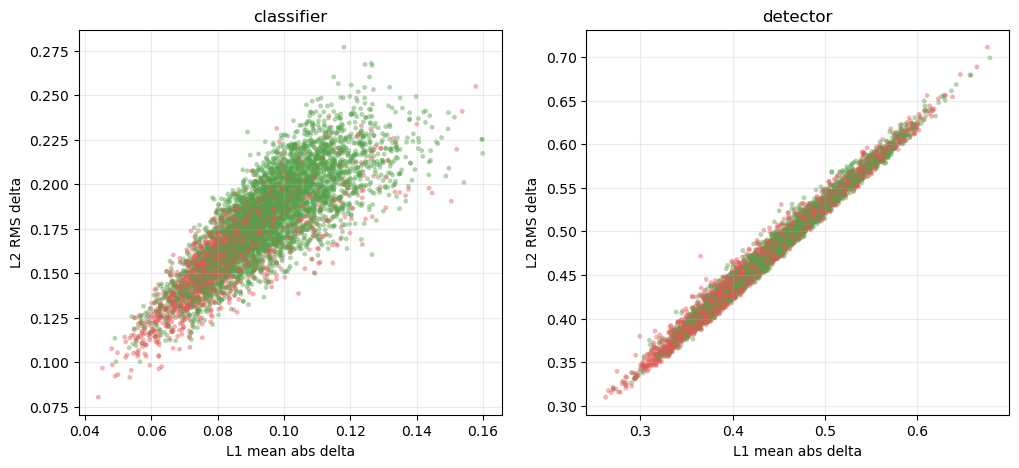

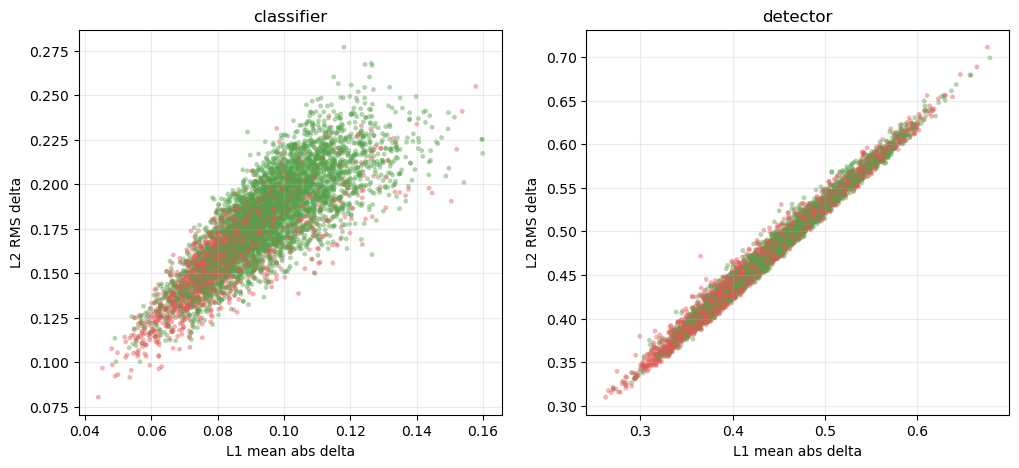

In [4]:
fig = plot_l1_l2_scatter(rows)
fig.savefig(roots.comparison_output / "l1_vs_l2_scatter.png", dpi=160, bbox_inches="tight")
fig

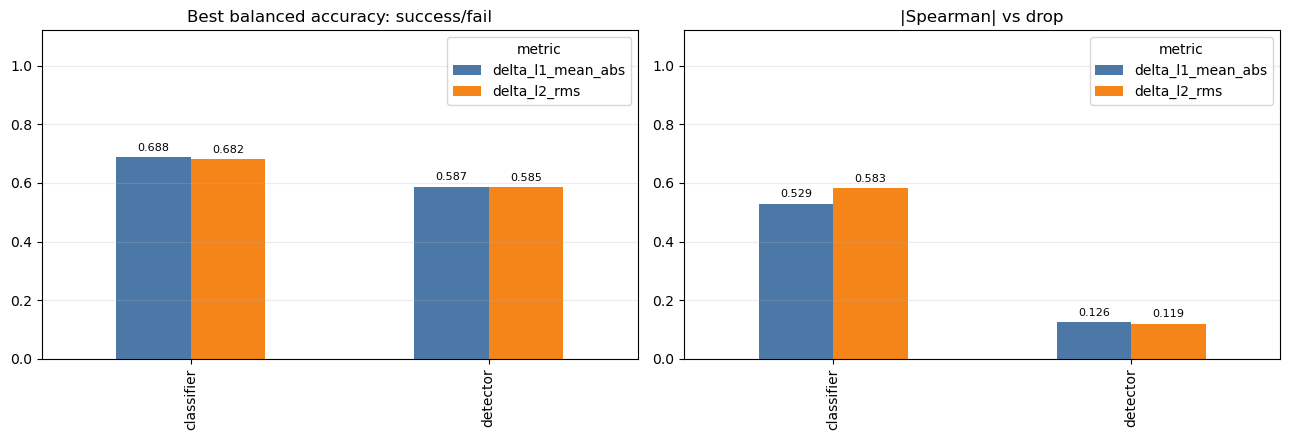

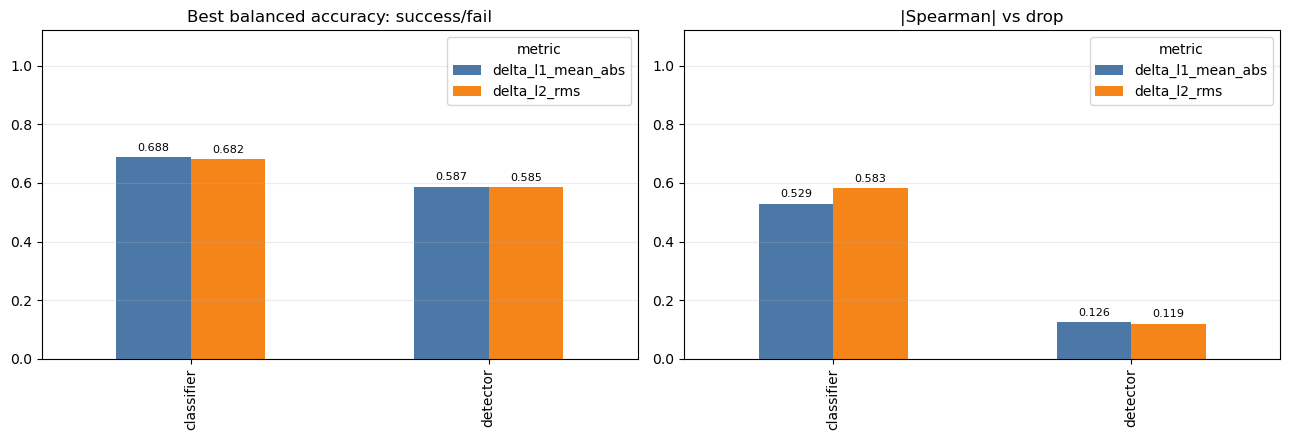

In [5]:
fig = plot_l1_l2_quality(quality, regression)
fig.savefig(roots.comparison_output / "l1_vs_l2_quality_and_drop_corr.png", dpi=160, bbox_inches="tight")
fig

In [ ]:
save_tables({"quality": quality, "regression": regression, "rows": rows}, roots.comparison_output, prefix="l1_vs_l2")
print("saved to:", roots.comparison_output)

saved to: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs


: 